# 기초통계 통합 프로젝트
## Part 1. 고객 구매 데이터 기술통계 및 이상치 분석

### 시나리오

온라인 쇼핑몰 데이터 분석팀은 고객 구매 데이터를 활용하여 고객의 전반적인 구매 특성을 파악하려고 합니다.

분석팀은 먼저 다음 내용을 확인해야 합니다.

- 고객의 평균적인 구매금액과 구매수량
- 고객 데이터가 얼마나 넓게 퍼져 있는지
- 구매금액 분포가 한쪽으로 치우쳐 진 구조인지
- 일반적인 고객과 차이가 큰 구매 데이터가 있는지

Part 1에서는 주요 기술통계량과 그래프를 이용하여 고객 구매 데이터의 기본 특성을 점검합니다.
이 결과는 이후 표본 분석, 상관관계 분석, 회귀예측에 공통으로 활용합니다.

### 과제 목표

- 평균, 중앙값, 분산, 표준편차를 계산할 수 있습니다.
- Q1, Q2, Q3를 계산하여 데이터의 위치를 확인할 수 있습니다.
- 히스토그램과 박스플롯으로 구매금액 분포를 확인할 수 있습니다.
- IQR 기준으로 이상치 후보를 찾을 수 있습니다.
- 계산 결과를 고객 구매 특성과 연결하여 설명할 수 있습니다.

### 사용 환경

- 결과물: `.ipynb` 파일 1개
- 사용 언어: Python 3.X
- 사용 라이브러리: pandas, matplotlib
- 사용 데이터: `online_shopping_customer_data.csv`


## 제공 코드. 고객 데이터 불러오기

아래 코드는 준비 코드이며 평가 대상이 아닙니다.

분석 대상 컬럼의 결측치가 있는 행을 제거하여 `analysis_df`를 생성합니다.
이후 Part에서도 동일한 전처리 기준을 사용합니다.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "online_shopping_customer_data.csv"

df = pd.read_csv(DATA_FILE)

analysis_columns = ["PurchaseAmount", "PurchaseQty", "Age", "ReviewScore"]

analysis_df = df.dropna(subset=analysis_columns).copy()

print("전체 데이터 크기:", df.shape)
print("분석 데이터 크기:", analysis_df.shape)
print("분석 대상 컬럼:", analysis_columns)

analysis_df[analysis_columns].head()


전체 데이터 크기: (500, 13)
분석 데이터 크기: (486, 13)
분석 대상 컬럼: ['PurchaseAmount', 'PurchaseQty', 'Age', 'ReviewScore']


,PurchaseAmount,PurchaseQty,Age,ReviewScore
0,86900.0,4,41,4.7
1,287500.0,7,27,4.9
2,242100.0,5,46,3.9
3,300500.0,5,48,5.0
4,171400.0,2,19,4.1


# 문제 1. 주요 기술통계량 계산

## 업무 상황

분석팀은 고객의 평균적인 구매 수준과 데이터의 분포를 한눈에 확인할 수 있는 요약표를 만들려고 합니다.

## 요구사항

1. `PurchaseAmount`, `PurchaseQty`, `Age`, `ReviewScore`의 평균을 계산합니다.
2. 각 컬럼의 중앙값을 계산합니다.
3. 각 컬럼의 분산과 표준편차를 계산합니다.
4. Q1, Q2, Q3를 계산합니다.
5. 계산 결과를 하나의 표로 정리하여 출력합니다.
6. `PurchaseAmount`의 평균과 중앙값을 비교합니다.


In [2]:
# 문제 1 코드를 작성하세요.

mean = analysis_df[analysis_columns].mean()
median = analysis_df[analysis_columns].median()
variance = analysis_df[analysis_columns].var()
std = analysis_df[analysis_columns].std()
q1 = analysis_df[analysis_columns].quantile(0.25)
q2 = analysis_df[analysis_columns].quantile(0.50)
q3 = analysis_df[analysis_columns].quantile(0.75)

summary = pd.DataFrame({
    "평균": mean,
    "중앙값": median,
    "분산": variance,
    "표준편차": std,
    "Q1": q1,
    "Q2": q2,
    "Q3": q3
})

print(summary)

print("PurchaseAmount 평균:", mean["PurchaseAmount"])
print("PurchaseAmount 중앙값:", median["PurchaseAmount"])

                           평균       중앙값            분산           표준편차  \
PurchaseAmount  229961.522634  216450.0  1.414358e+10  118926.782556   
PurchaseQty          3.837449       4.0  4.045687e+00       2.011389   
Age                 37.940329      38.0  9.768509e+01       9.883577   
ReviewScore          3.929218       3.9  4.224023e-01       0.649925   

                      Q1        Q2        Q3  
PurchaseAmount  158225.0  216450.0  280525.0  
PurchaseQty          2.0       4.0       5.0  
Age                 31.0      38.0      44.0  
ReviewScore          3.5       3.9       4.4  
PurchaseAmount 평균: 229961.52263374487
PurchaseAmount 중앙값: 216450.0


# 문제 2. 구매금액 분포와 이상치 후보 확인

## 업무 상황

고객 구매금액이 특정 구간에 집중되어 있는지 확인하고,
일반적인 고객과 차이가 큰 고액 또는 저액 구매 데이터를 찾으려고 합니다.

## 요구사항

1. `PurchaseAmount`의 히스토그램을 생성합니다.
2. `PurchaseAmount`의 박스플롯을 생성합니다.
3. Q1, Q3, IQR을 계산합니다.
4. IQR 기준의 하한값과 상한값을 계산합니다.
5. 하한값보다 작거나 상한값보다 큰 데이터를 이상치 후보로 추출합니다.
6. 이상치 후보의 개수와 `CustomerID`, `PurchaseAmount`를 출력합니다.

## IQR 기준

- 하한값: `Q1 - 1.5 × IQR`
- 상한값: `Q3 + 1.5 × IQR`


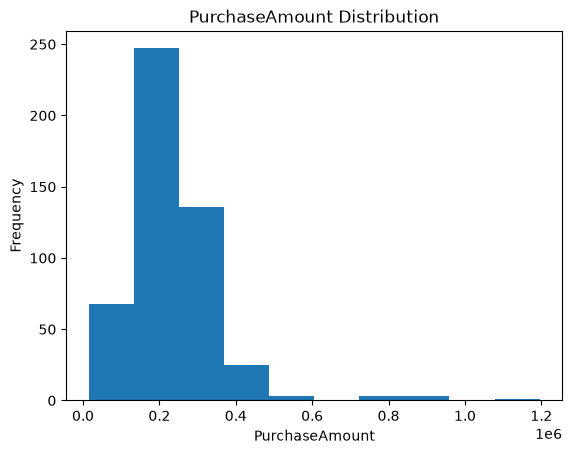

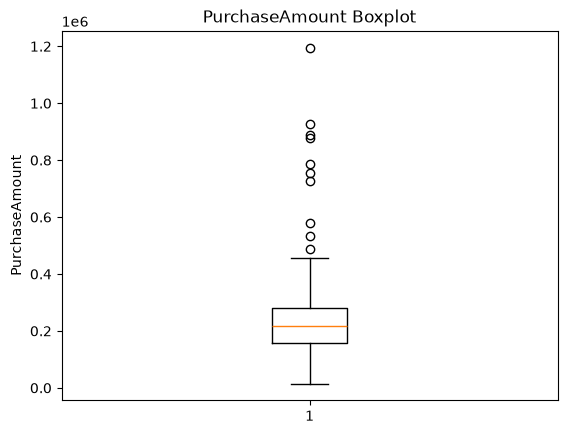

이상치 후보 개수: 10
    CustomerID  PurchaseAmount
31    CUST0032        788100.0
34    CUST0035        876500.0
77    CUST0078        889400.0
177   CUST0178        580400.0
179   CUST0180        489400.0
281   CUST0282        534500.0
299   CUST0300       1195500.0
319   CUST0320        925400.0
368   CUST0369        755900.0
390   CUST0391        725200.0


In [3]:
# 문제 2 코드를 작성하세요.

purchase_amount = analysis_df["PurchaseAmount"]

plt.hist(purchase_amount)
plt.xlabel("PurchaseAmount")
plt.ylabel("Frequency")
plt.title("PurchaseAmount Distribution")
plt.show()

plt.boxplot(purchase_amount)
plt.ylabel("PurchaseAmount")
plt.title("PurchaseAmount Boxplot")
plt.show()

q1 = purchase_amount.quantile(0.25)
q3 = purchase_amount.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = analysis_df[(purchase_amount < lower) | (purchase_amount > upper)]

print("이상치 후보 개수:", len(outliers))
print(outliers[["CustomerID", "PurchaseAmount"]])

# 문제 3. 고객 구매 특성 해석

## 업무 상황

분석팀은 계산 결과를 마케팅 담당자가 이해할 수 있도록
구매금액의 기본적인 분포 특성으로 정리해야 합니다.

## 필수 요구사항

다음 내용을 포함하여 3문장 이상 작성합니다.

1. `PurchaseAmount`의 평균과 중앙값 중 어떤 값이 더 큰지 설명합니다.
2. 히스토그램과 박스플롯에서 확인한 구매금액 분포의 특징을 설명합니다.
3. IQR 기준으로 탐지된 이상치 후보의 개수를 설명합니다.


In [4]:
# 문제 3 해석에 필요한 값을 출력하고, 아래 마크다운 셀에 해석을 작성하세요.
print("PurchaseAmount 평균:", mean["PurchaseAmount"])
print("PurchaseAmount 중앙값:", median["PurchaseAmount"])
print("이상치 후보 개수:", len(outliers))

PurchaseAmount 평균: 229961.52263374487
PurchaseAmount 중앙값: 216450.0
이상치 후보 개수: 10


###### PurchaseAmount의 평균은 약 229,962원으로 중앙값 216,450원보다 크다. 
###### 따라서 일부 고객의 높은 구매금액이 전체 평균을 높이고 있는 것으로 볼 수 있다. 
###### 히스토그램과 박스플롯을 확인한 결과 대부분의 구매금액은 일정한 구간에 집중되어 있지만 
###### 일부 고액 구매금액이 존재하여 오른쪽으로 치우친 분포를 보인다. 
###### IQR 기준으로 이상치 후보를 탐지한 결과 총 10개의 이상치 후보가 확인되었다.

# 심화 문제. 이상치 후보의 업무적 의미 분석

이 문제는 필수 문제가 아니며, **심화 문제**입니다.

## 업무 상황

IQR 기준을 벗어난 구매금액이 발견되었지만,
해당 고객을 분석 데이터에서 바로 제거해도 되는지는 추가 확인이 필요합니다.

## 심화 요구사항

다음 내용을 포함하여 3문장 이상 작성합니다.

1. 이상치 후보가 입력 오류가 아닌 정상적인 고액 구매일 수 있는 사례를 제시합니다.
2. 이상치 후보를 바로 삭제하면 안 되는 이유를 설명합니다.
3. 이상치 처리 전에 추가로 확인해야 할 고객 또는 구매 정보를 작성합니다.


In [ ]:
# 심화 문제 해석에 필요한 이상치 후보를 확인하세요.


# 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 기술통계 요약표 | 평균, 중앙값, 분산, 표준편차, Q1, Q2, Q3 |
| 구매금액 분포 | 히스토그램과 박스플롯 |
| 이상치 탐지 결과 | IQR 기준, 이상치 후보 개수와 고객 정보 |
| 기본 해석 | 구매금액 분포와 이상치 후보 개수 설명 |
| 심화 해석 | 이상치의 업무적 의미와 처리 전 확인 사항(선택) |

# 제출 전 체크리스트

## 필수 문제

- [ ] 평균과 중앙값을 계산했습니다.
- [ ] 분산과 표준편차를 계산했습니다.
- [ ] Q1, Q2, Q3를 계산했습니다.
- [ ] 기술통계량을 하나의 표로 정리했습니다.
- [ ] 히스토그램과 박스플롯을 생성했습니다.
- [ ] IQR 기준으로 이상치 후보를 찾았습니다.
- [ ] 구매금액 분포와 이상치 후보 개수를 설명했습니다.

## 심화 문제

- [ ] 이상치 후보가 정상적인 고액 구매일 수 있는 사례를 작성했습니다.
- [ ] 이상치를 바로 삭제하면 안 되는 이유를 설명했습니다.
- [ ] 이상치 처리 전에 확인할 정보를 작성했습니다.
